# Ouroboros Analysis: Breast Cancer Dataset

Dataset from the paper "A comprehensive single-cell map of T cell exhaustion-associated immune environments in human breast cancer" accessible at: https://www.nature.com/articles/s41467-022-35238-w. 


### 0. Dataset Availability and Loading 

The raw and processed single cell RNA-seq data generated from this study are deposited in the ArrayExpress database at EMBL-EBI under accession number E-MTAB-10607. Also available on the ENA under ERP130387. 

Processed data include metadata and matrix files available for each sample, downloaded using ftp via the file E-MTAB-10607-unix-ftp.txt/

In [ ]:
cat ./E-MTAB-10607-unix-ftp.txt | sh

### 1. Generating a .h5ad File

From each dataset, for each sample (14 in total), I have:
- a matrix of gene expression (genes x cells)
- a metadata table (cells x attributes)

In [1]:
# activate environment ouroboros (Kernel)
# load in packages 

import scanpy as sc
import pandas as pd
import ouroboros as obo

#### 1.1 Loading Count Matrix

In [34]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338
# Step 1: Load count matrix
counts_BB011 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB011_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB111 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB111_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB129 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB129_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB165 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB165_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB171 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB171_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB184 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB184_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB338 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB338_singlecell_count_matrix.txt", sep="\t", index_col=0)

# Clean column names: remove trailing ".1"
clean_barcodes_BB011 = [bc.replace(".1", "") for bc in counts_BB011.columns]
clean_barcodes_BB111 = [bc.replace(".1", "") for bc in counts_BB111.columns]
clean_barcodes_BB129 = [bc.replace(".1", "") for bc in counts_BB129.columns]
clean_barcodes_BB165 = [bc.replace(".1", "") for bc in counts_BB165.columns]
clean_barcodes_BB171 = [bc.replace(".1", "") for bc in counts_BB171.columns]
clean_barcodes_BB184 = [bc.replace(".1", "") for bc in counts_BB184.columns]
clean_barcodes_BB338 = [bc.replace(".1", "") for bc in counts_BB338.columns]

# Add sample prefix to match metadata barcodes
counts_BB011.columns = [f"TBB011_{bc}" for bc in clean_barcodes_BB011]
counts_BB111.columns = [f"TBB111_{bc}" for bc in clean_barcodes_BB111]
counts_BB129.columns = [f"TBB129_{bc}" for bc in clean_barcodes_BB129]
counts_BB165.columns = [f"TBB165_{bc}" for bc in clean_barcodes_BB165]
counts_BB171.columns = [f"TBB171_{bc}" for bc in clean_barcodes_BB171]
counts_BB184.columns = [f"TBB184_{bc}" for bc in clean_barcodes_BB184]
counts_BB338.columns = [f"TBB338_{bc}" for bc in clean_barcodes_BB338]


In [35]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330
# Step 1: Load count matrix
counts_BB035 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB035_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB075 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB075_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB102 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB102_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB212 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB212_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB214 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB214_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB226 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB226_singlecell_count_matrix.txt", sep="\t", index_col=0)
counts_BB330 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB330_singlecell_count_matrix.txt", sep="\t", index_col=0)

# Clean column names: remove trailing ".1"
clean_barcodes_BB035 = [bc.replace(".1", "") for bc in counts_BB035.columns]
clean_barcodes_BB075 = [bc.replace(".1", "") for bc in counts_BB075.columns]
clean_barcodes_BB102 = [bc.replace(".1", "") for bc in counts_BB102.columns]
clean_barcodes_BB212 = [bc.replace(".1", "") for bc in counts_BB212.columns]
clean_barcodes_BB214 = [bc.replace(".1", "") for bc in counts_BB214.columns]
clean_barcodes_BB226 = [bc.replace(".1", "") for bc in counts_BB226.columns]
clean_barcodes_BB330 = [bc.replace(".1", "") for bc in counts_BB330.columns]

# Add sample prefix to match metadata barcodes
counts_BB035.columns = [f"TBB035_{bc}" for bc in clean_barcodes_BB035]
counts_BB075.columns = [f"TBB075_{bc}" for bc in clean_barcodes_BB075]
counts_BB102.columns = [f"TBB102_{bc}" for bc in clean_barcodes_BB102]
counts_BB212.columns = [f"TBB212_{bc}" for bc in clean_barcodes_BB212]
counts_BB214.columns = [f"TBB214_{bc}" for bc in clean_barcodes_BB214]
counts_BB226.columns = [f"TBB226_{bc}" for bc in clean_barcodes_BB226]
counts_BB330.columns = [f"TBB330_{bc}" for bc in clean_barcodes_BB330]



#### 1.2 Loading Metadata

In [36]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338
# Step 2: Load metadata
meta_BB011 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB011_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB111 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB111_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB129 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB129_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB165 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB165_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB171 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB171_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB184 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB184_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB338 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB338_complete_singlecell_metadata.txt", sep="\t", index_col=0)


In [37]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330
# Step 2: Load metadata
meta_BB035 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB035_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB075 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB075_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB102 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB102_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB212 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB212_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB214 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB214_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB226 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB226_complete_singlecell_metadata.txt", sep="\t", index_col=0)
meta_BB330 = pd.read_csv("/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data/TBB330_complete_singlecell_metadata.txt", sep="\t", index_col=0)

#### 1.3 Sanity Check - Ensure Cells Match

In [38]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338
# Step 3: Ensure cells match
counts_BB011 = counts_BB011.loc[:, meta_BB011.index]  # Optional: reorder columns to match metadata
counts_BB111 = counts_BB111.loc[:, meta_BB111.index]
counts_BB129 = counts_BB129.loc[:, meta_BB129.index]
counts_BB165 = counts_BB165.loc[:, meta_BB165.index]
counts_BB171 = counts_BB171.loc[:, meta_BB171.index]
counts_BB184 = counts_BB184.loc[:, meta_BB184.index]
counts_BB338 = counts_BB338.loc[:, meta_BB338.index]


In [39]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330
# Step 3: Ensure cells match
counts_BB035 = counts_BB035.loc[:, meta_BB035.index]
counts_BB075 = counts_BB075.loc[:, meta_BB075.index]
counts_BB102 = counts_BB102.loc[:, meta_BB102.index]
counts_BB212 = counts_BB212.loc[:, meta_BB212.index]
counts_BB214 = counts_BB214.loc[:, meta_BB214.index]
counts_BB226 = counts_BB226.loc[:, meta_BB226.index]
counts_BB330 = counts_BB330.loc[:, meta_BB330.index]

#### 1.4 Create AnnData Object

In [41]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338
# Step 4: Create AnnData object
adata_BB011 = sc.AnnData(X=counts_BB011.T)  # transpose to cells × genes
adata_BB011.obs = meta_BB011

adata_BB111 = sc.AnnData(X=counts_BB111.T)
adata_BB111.obs = meta_BB111

adata_BB129 = sc.AnnData(X=counts_BB129.T)
adata_BB129.obs = meta_BB129

adata_BB165 = sc.AnnData(X=counts_BB165.T)
adata_BB165.obs = meta_BB165

adata_BB171 = sc.AnnData(X=counts_BB171.T)
adata_BB171.obs = meta_BB171

adata_BB184 = sc.AnnData(X=counts_BB184.T)
adata_BB184.obs = meta_BB184

adata_BB338 = sc.AnnData(X=counts_BB338.T)
adata_BB338.obs = meta_BB338


In [42]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330
# Step 4: Create AnnData object
adata_BB035 = sc.AnnData(X=counts_BB035.T)
adata_BB035.obs = meta_BB035

adata_BB075 = sc.AnnData(X=counts_BB075.T)
adata_BB075.obs = meta_BB075

adata_BB102 = sc.AnnData(X=counts_BB102.T)
adata_BB102.obs = meta_BB102

adata_BB212 = sc.AnnData(X=counts_BB212.T)
adata_BB212.obs = meta_BB212

adata_BB214 = sc.AnnData(X=counts_BB214.T)
adata_BB214.obs = meta_BB214

adata_BB226 = sc.AnnData(X=counts_BB226.T)
adata_BB226.obs = meta_BB226

adata_BB330 = sc.AnnData(X=counts_BB330.T)
adata_BB330.obs = meta_BB330

#### 1.5 Save as h5ad

In [43]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338
# Step 5: Save as h5ad
adata_BB011.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB011.h5ad")
adata_BB111.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB111.h5ad")
adata_BB129.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB129.h5ad")
adata_BB165.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB165.h5ad")
adata_BB171.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB171.h5ad")
adata_BB184.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB184.h5ad")
adata_BB338.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB338.h5ad")

... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_c

In [44]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330
# Step 5: Save as h5ad
adata_BB035.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB035.h5ad")
adata_BB075.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB075.h5ad")
adata_BB102.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB102.h5ad")
adata_BB212.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB212.h5ad")
adata_BB214.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB214.h5ad")
adata_BB226.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB226.h5ad")
adata_BB330.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/BB330.h5ad")


... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical
... storing 'sample' as categorical
... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_c

#### 1.6 Combining IE1 and IE2 Datasets

In [45]:
import os

In [47]:
# IE1 group data -> BB011, BB111, BB129, BB165, BB171, BB184, BB338

# List all your sample prefixes
samples_IE1 = [
    "TBB011", "TBB111", "TBB129", "TBB165", 
    "TBB171", "TBB184", "TBB338"
]

# Define the path to your raw data files
path_prefix_IE1 = "/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data"

adatas_IE1 = []

for sample_IE1 in samples_IE1:
    counts_IE1 = pd.read_csv(f"{path_prefix_IE1}/{sample_IE1}_singlecell_count_matrix.txt", sep="\t", index_col=0)
    meta_IE1 = pd.read_csv(f"{path_prefix_IE1}/{sample_IE1}_complete_singlecell_metadata.txt", sep="\t", index_col=0)
    
    # Clean barcode names if needed
    clean_barcodes_IE1 = [bc.replace(".1", "") for bc in counts_IE1.columns]
    counts_IE1.columns = [f"{sample_IE1}_{bc}" for bc in clean_barcodes_IE1]
    
    # Align counts to metadata
    counts_IE1 = counts_IE1.loc[:, meta_IE1.index]
    
    # Create AnnData object
    adata_IE1 = sc.AnnData(X=counts_IE1.T)
    adata_IE1.obs = meta_IE1
    adata_IE1.obs["sample"] = sample_IE1  # Track sample origin
    adatas_IE1.append(adata_IE1)

# Concatenate all samples
adata_all_IE1 = adatas_IE1[0].concatenate(adatas_IE1[1:], batch_key="sample")

# Save to .h5ad file
adata_all_IE1.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/all_samples_IE1.h5ad")



... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical


In [48]:
# IE2 group data -> BB035, BB075, BB102, BB212, BB214, BB226, BB330

# List all your sample prefixes
samples_IE2 = [
    "TBB035", "TBB075", "TBB102", 
    "TBB212", "TBB214", "TBB226", "TBB330"
]

# Define the path to your raw data files
path_prefix_IE2 = "/projects/steiflab/scratch/mtong/breast_cancer/data/raw_data"

adatas_IE2 = []

for sample_IE2 in samples_IE2:
    counts_IE2 = pd.read_csv(f"{path_prefix_IE2}/{sample_IE2}_singlecell_count_matrix.txt", sep="\t", index_col=0)
    meta_IE2 = pd.read_csv(f"{path_prefix_IE2}/{sample_IE2}_complete_singlecell_metadata.txt", sep="\t", index_col=0)
    
    # Clean barcode names if needed
    clean_barcodes_IE2 = [bc.replace(".1", "") for bc in counts_IE2.columns]
    counts_IE2.columns = [f"{sample_IE2}_{bc}" for bc in clean_barcodes_IE2]
    
    # Align counts to metadata
    counts_IE2 = counts_IE2.loc[:, meta_IE2.index]
    
    # Create AnnData object
    adata_IE2 = sc.AnnData(X=counts_IE2.T)
    adata_IE2.obs = meta_IE2
    adata_IE2.obs["sample"] = sample_IE2  # Track sample origin
    adatas_IE2.append(adata_IE2)

# Concatenate all samples
adata_all_IE2 = adatas_IE2[0].concatenate(adatas_IE2[1:], batch_key="sample")

# Save to .h5ad file
adata_all_IE2.write("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/all_samples_IE2.h5ad")


... storing 'IE' as categorical
... storing 'cell_type' as categorical
... storing 'Tcell_cluster' as categorical
... storing 'Tcell_metacluster' as categorical
... storing 'myeloid_cluster' as categorical
... storing 'myeloid_metacluster' as categorical


### 2. Ouroboros 

Using the concatenated samples for IE1 and IE2

#### 2.1 Load Packages 

In [ ]:
# load additional packages
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns

#### 2.2 Reading in Datasets



In [ ]:
# Read in test dataset - subsetted to existing features
adata_h5ad_IE1 = sc.read_h5ad("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/all_samples_IE1.h5ad")
adata_h5ad_IE1

adata_h5ad_IE2 = sc.read_h5ad("/projects/steiflab/scratch/mtong/breast_cancer/data/h5ad_data/all_samples_IE2.h5ad")
adata_h5ad_IE2

AnnData object with n_obs × n_vars = 69188 × 21959
    obs: 'sample', 'IE', 'excl_doublet', 'excl_QC', 'cell_type', 'Tcell_cluster', 'Tcell_metacluster', 'myeloid_cluster', 'myeloid_metacluster'

In [ ]:
# Check for missing genes
missing_genes_E1 = obo.check_genes(adata_h5ad_IE1)

# If any are missing, list them
if missing_genes_E1:
    print("Missing feature genes:")
    for gene in missing_genes_E1:
        print(gene)
else:
    print("All Ouroboros feature genes are present!")


Some feature genes are missing from your anndata
Missing feature genes:
H1-3
H4C8
CLTRN
H1-5
H1-1
H2AC20
H1-4
H2BC11
IRAG1


In [ ]:
# Check for missing genes
missing_genes_E2 = obo.check_genes(adata_h5ad_IE2)

# If any are missing, list them
if missing_genes_E2:
    print("Missing feature genes:")
    for gene in missing_genes_E2:
        print(gene)
else:
    print("All Ouroboros feature genes are present!")

Some feature genes are missing from your anndata
Missing feature genes:
H1-3
H4C8
CLTRN
H1-5
H1-1
H2AC20
H1-4
H2BC11
IRAG1


#### 2.3 QC Metrics

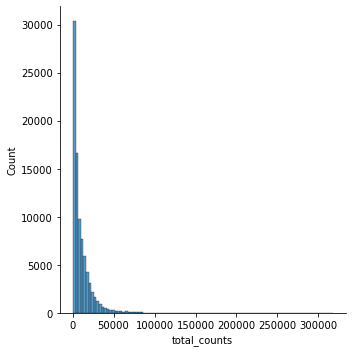

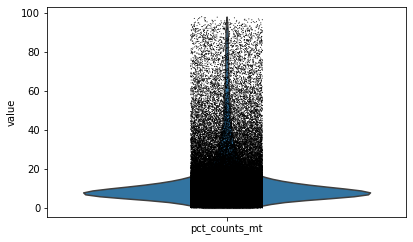

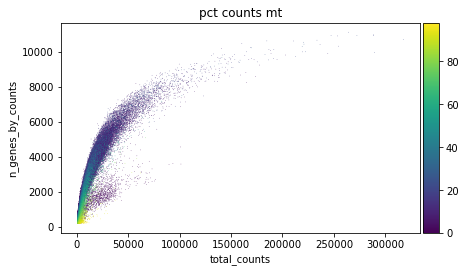

In [ ]:
# Continue with normal scanpy filtering

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata_h5ad_IE1.var["mt"] = adata_h5ad_IE1.var_names.str.startswith("MT-")
# ribosomal genes
adata_h5ad_IE1.var["ribo"] = adata_h5ad_IE1.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_h5ad_IE1.var["hb"] = adata_h5ad_IE1.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics with scanpy 
sc.pp.calculate_qc_metrics(
    adata_h5ad_IE1,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True
)

# Plot QC metrics
p1_IE1 = sns.displot(adata_h5ad_IE1.obs["total_counts"], bins=100, kde=False)
p2_IE1 = sc.pl.violin(adata_h5ad_IE1, "pct_counts_mt")
p3_IE1 = sc.pl.scatter(adata_h5ad_IE1, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

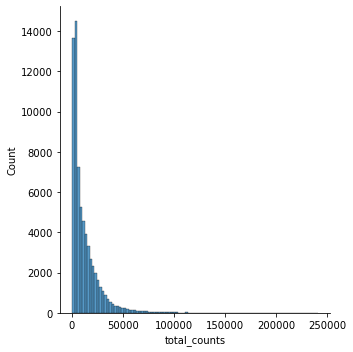

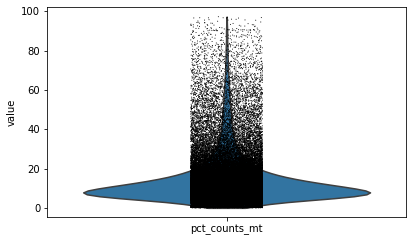

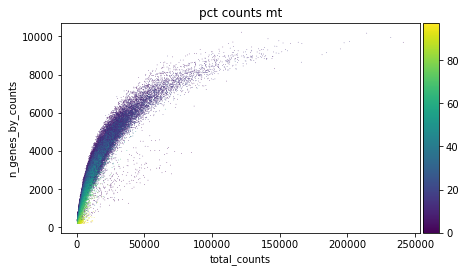

In [ ]:
# Continue with normal scanpy filtering

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata_h5ad_IE2.var["mt"] = adata_h5ad_IE2.var_names.str.startswith("MT-")
# ribosomal genes
adata_h5ad_IE2.var["ribo"] = adata_h5ad_IE2.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_h5ad_IE2.var["hb"] = adata_h5ad_IE2.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics with scanpy 
sc.pp.calculate_qc_metrics(
    adata_h5ad_IE2,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True
)

# Plot QC metrics
p1_IE2 = sns.displot(adata_h5ad_IE2.obs["total_counts"], bins=100, kde=False)
p2_IE2 = sc.pl.violin(adata_h5ad_IE2, "pct_counts_mt")
p3_IE2 = sc.pl.scatter(adata_h5ad_IE2, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

#### 2.4 Filtering

In [ ]:
# 1. Filter out low-quality cells
sc.pp.filter_cells(adata_h5ad_IE1, min_genes=20)

# 2. Filter genes but keep all Ouroboros feature genes
feature_genes_IE1 = obo.read_in_features()
gene_counts_IE1 = np.array((adata_h5ad_IE1.X > 0).sum(axis=0)).flatten()
gene_mask_IE1 = gene_counts_IE1 >= 3
gene_names_IE1 = adata_h5ad_IE1.var_names.to_numpy()
gene_mask_IE1 |= np.isin(gene_names_IE1, list(feature_genes_IE1))
adata_h5ad_IE1 = adata_h5ad_IE1[:, gene_mask_IE1].copy()

In [ ]:
# 1. Filter out low-quality cells
sc.pp.filter_cells(adata_h5ad_IE2, min_genes=20)

# 2. Filter genes but keep all Ouroboros feature genes
feature_genes_IE2 = obo.read_in_features()
gene_counts_IE2 = np.array((adata_h5ad_IE2.X > 0).sum(axis=0)).flatten()
gene_mask_IE2 = gene_counts_IE2 >= 3
gene_names_IE2 = adata_h5ad_IE2.var_names.to_numpy()
gene_mask_IE2 |= np.isin(gene_names_IE2, list(feature_genes_IE2))
adata_h5ad_IE2 = adata_h5ad_IE2[:, gene_mask_IE2].copy()

#### 2.5 Run Ouroboros

In [ ]:
# The first step is to save a copy of your filtered adata object with adata.layers['raw_counts'] - this layer is what Ouroboros will run on

# save your raw counts 
adata_h5ad_IE1.layers['raw_counts'] = adata_h5ad_IE1.X.copy()
adata_h5ad_IE2.layers['raw_counts'] = adata_h5ad_IE2.X.copy()

# write the adata to a H5AD
adata_h5ad_IE1.write_h5ad('filtered_IE1.h5ad')
adata_h5ad_IE2.write_h5ad('filtered_IE2.h5ad')

In [ ]:
# Then you can run Ouroboros on the saved h5ad 
z_df_E1 = obo.run_ouroboros('filtered_IE1.h5ad', 'h5ad', species = 'human', outdir = '.')